In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

In [4]:

df = sns.load_dataset("tips")
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


## 1. Univariate Analysis (1 Variable at a Time)

Here we look at one variable independentdy to check centrai tendency, spread, outiens, or catagan fimqunies

## A. Numerical Variable: total blA

 - We want to see the distribution of bill amounts

In [5]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64


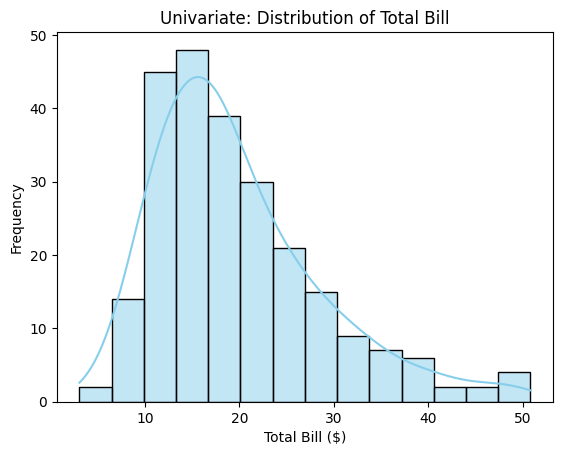

In [6]:
print(df["total_bill"].describe())

# Visualization: Histogram + KDE (Kernel Density Estimate)
sns.histplot(df["total_bill"], kde=True, color='skyblue')
plt.title("Univariate: Distribution of Total Bill")
plt.xlabel("Total Bill ($)")
plt.ylabel("Frequency")
plt.show()

## B. Categorical Variable: day

We want to see how many transactions happen on each day.

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


C:\Users\nevil\AppData\Local\Temp\ipykernel_16552\1802629009.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="day", palette="Set2")


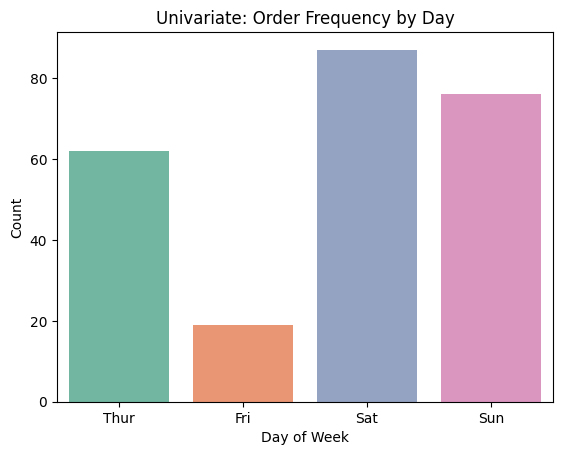

In [7]:
print(df["day"].value_counts())

# Visualization: Bar Chart / Count Plot
sns.countplot(data=df, x="day", palette="Set2")
plt.title("Univariate: Order Frequency by Day")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.show()

## B. Categorical Variable: day

We want to see how many transactions happen on each day.

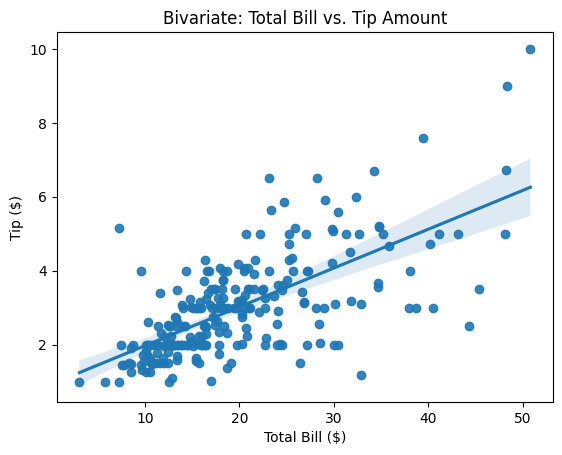

Correlation between Total Bill and Tip: 0.68


In [8]:
# Scatter Plot + Linear Trend Line
sns.regplot(data=df, x="total_bill", y="tip", scatter_kws={"alpha": 0.9})
plt.title("Bivariate: Total Bill vs. Tip Amount")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.show()

# Pearson Correlation Coefficient
correlation = df["total_bill"].corr(df["tip"])
print(f"Correlation between Total Bill and Tip: {correlation:.2f}")

## Categorical vs. Numerical: day vs. total bill

C:\Users\nevil\AppData\Local\Temp\ipykernel_16552\1366607349.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="day", y="total_bill", palette="Set3")


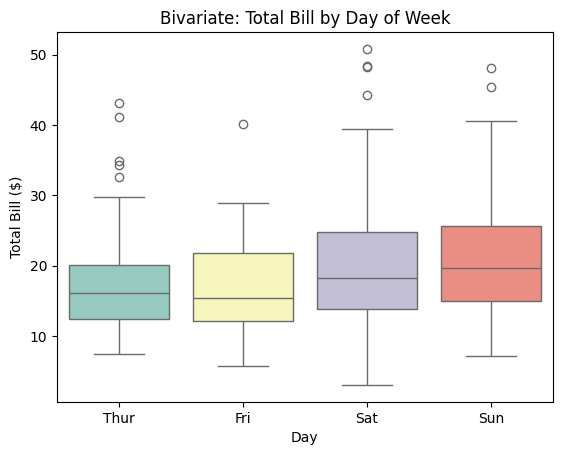

In [9]:
# Boxplot to compare distributions across groups
sns.boxplot(data=df, x="day", y="total_bill", palette="Set3")
plt.title("Bivariate: Total Bill by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Bill ($)")
plt.show()

## 3. Multivariate Analysis (3+ Variables Together)

• Multivariate analysis reveals complex interactions by examining three or more features at once.

One popular way to view multiple bivariate relationships at once across groups is a Pair Plot

A. 3 Variables: total bill vs. tip split by smoker status

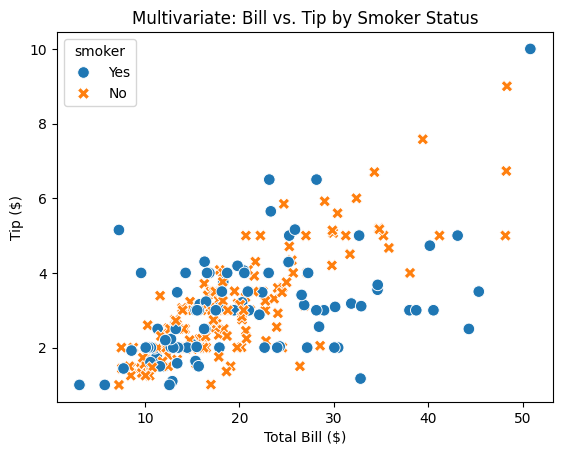

In [10]:
# Scatter plot hue mapping (3 variables: total_bill, tip, smoker)
sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="smoker",
    style="smoker",
    s=70,
)
plt.title("Multivariate: Bill vs. Tip by Smoker Status")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.show()

## B. Correlation Heatmap (All Numerical Variables)

- Analyze relationships across total_bill, tip, and size (party size) simultaneously.

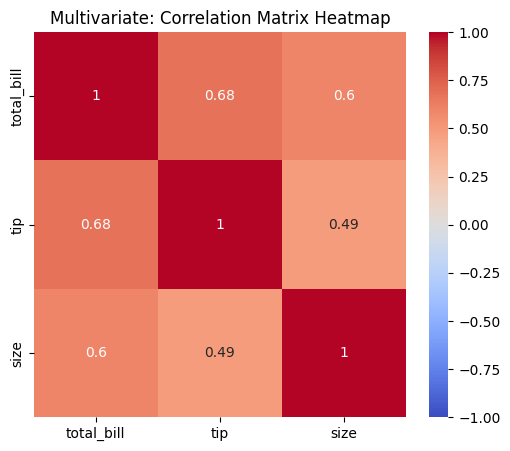

In [11]:
# Compute correlation matrix for numeric columns
numeric_df = df.select_dtypes(include=["float64", "int64"])
corr_matrix = numeric_df.corr()

# Heatmap visualization
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Multivariate: Correlation Matrix Heatmap")
plt.show()